# Assignment-4 COMP-5970 Jacob Murrah
## README
Design a small CNN from scratch (5–10 layers), train it on CIFAR-10, then
upgrade it with residual connections and compare. Finally, pretrain one of
your models with a self-supervised objective and fine-tune on labels. You’ll
analyze accuracy, data efficiency, convergence, and learned features.

## Dependencies
- **Python 3.x**
- **numpy**
- **matplotlib**
- **pytorch**
- **tensorflow**
- **scikit learn**
- **seaborn**

*Note: If you are running this notebook in Google Colab, all the required packages are pre-installed.*

## Instructions
1. **Run All Cells:** Please click on \"Runtime\" > \"Run all\" to execute the entire notebook sequentially.
2. **Review the Outputs:** The notebook is organized into several sections. Ensure that all cells run without errors.

## GenAI Usage Declaration
a

## Statement of Contribution
This was an individual project and I did everything in it.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import tensorflow as tf
import torchvision, torchvision.transforms as transforms
from torch.utils.data import Subset
from collections import defaultdict
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [16]:
# Load CIFAR-10 dataset
CIFAR_CLASSES = [
    'plane',
    'car',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ]),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, transform=train_transform, download=True
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, transform=test_transform, download=True
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=96, num_workers=2, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=96, shuffle=True
)



In [17]:
class EncoderWrapper(nn.Module):
    def __init__(
        self,
        encoder,
        latent_dim=128,
        output_dim=10
    ):
        super().__init__()
        self.encoder = encoder

        self.head = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        return self.head(features)

def train_epoch(m, criterion, opt, loader):
    m.train()
    total, correct, loss_sum = 0, 0, 0.0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        opt.zero_grad()

        logits = m(images)
        loss = criterion(logits, labels)

        loss.backward()
        opt.step()

        pred = torch.argmax(logits, dim=1)
        correct += (pred == labels).sum().item()
        loss_sum += loss.item() * labels.size(0)

        total += labels.size(0)

    return loss_sum / total, correct / total

def test_epoch(m, criterion):
    m.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = m(images)
            loss = criterion(logits, labels)

            pred = torch.argmax(logits, dim=1)
            correct += (pred == labels).sum().item()
            loss_sum += loss.item() * labels.size(0)

            total += labels.size(0)

    return loss_sum / total, correct / total

def train_model(m, c, o, l):
    history = defaultdict(list)
    for epoch in range(30):
        tr_loss, tr_acc = train_epoch(m, c, o, l)
        te_loss, te_acc = test_epoch(m, c)

        print(
            "ep%d: tr_loss: %.3f, tr_acc: %.3f | te_loss: %.3f, te_acc: %.3f" % (
                epoch, tr_loss, tr_acc, te_loss, te_acc
            )
        )

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

    return history

# Task 1) Small CNN (from scratch)
Implement and train a compact CNN classifier on CIFAR-10 with the
following specifications:
- 5–10 learnable layers (conv/normalization/activation/linear count
toward depth; pooling doesn’t).
- ≤ 1.5M parameters (show a param count).
- Use standard training (cross-entropy) and reasonable augments
(random crop/flip, optional color jitter).
- Train to reasonable test accuracy (don’t overtrain; ~20–30 epochs or
early stopping is fine).

## Description of Approach
a

In [18]:
class SimpleCNNEncoder(nn.Module):
    def __init__(self, in_channels=3, latent_ch=128):
        super().__init__()
        self.dropout = nn.Dropout(0.5)

        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=64,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(128)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(256)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc = nn.Linear(
            in_features=256 * 4 * 4, out_features=latent_ch
        )

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [19]:
model1 = EncoderWrapper(encoder=SimpleCNNEncoder()).to(device)
opt1 = torch.optim.SGD(
    model1.parameters(), lr=0.001, weight_decay=1e-4, momentum=0.9
)
criterion1 = nn.CrossEntropyLoss()

history1 = train_model(model1, criterion1, opt1, train_loader)

ep0: tr_loss: 1.822, tr_acc: 0.328 | te_loss: 1.409, te_acc: 0.501
ep1: tr_loss: 1.489, tr_acc: 0.454 | te_loss: 1.245, te_acc: 0.556
ep2: tr_loss: 1.332, tr_acc: 0.516 | te_loss: 1.132, te_acc: 0.595
ep3: tr_loss: 1.234, tr_acc: 0.558 | te_loss: 1.009, te_acc: 0.640
ep4: tr_loss: 1.166, tr_acc: 0.583 | te_loss: 0.976, te_acc: 0.652
ep5: tr_loss: 1.111, tr_acc: 0.604 | te_loss: 0.925, te_acc: 0.671
ep6: tr_loss: 1.077, tr_acc: 0.620 | te_loss: 0.885, te_acc: 0.689
ep7: tr_loss: 1.034, tr_acc: 0.634 | te_loss: 0.849, te_acc: 0.701
ep8: tr_loss: 1.006, tr_acc: 0.646 | te_loss: 0.843, te_acc: 0.703
ep9: tr_loss: 0.979, tr_acc: 0.653 | te_loss: 0.784, te_acc: 0.726
ep10: tr_loss: 0.953, tr_acc: 0.665 | te_loss: 0.772, te_acc: 0.731
ep11: tr_loss: 0.938, tr_acc: 0.671 | te_loss: 0.797, te_acc: 0.718
ep12: tr_loss: 0.919, tr_acc: 0.678 | te_loss: 0.767, te_acc: 0.730
ep13: tr_loss: 0.903, tr_acc: 0.682 | te_loss: 0.726, te_acc: 0.746
ep14: tr_loss: 0.880, tr_acc: 0.689 | te_loss: 0.719, te_a

Task 1 Part a) **Model diagram**

hello world

Total parameters: 904586


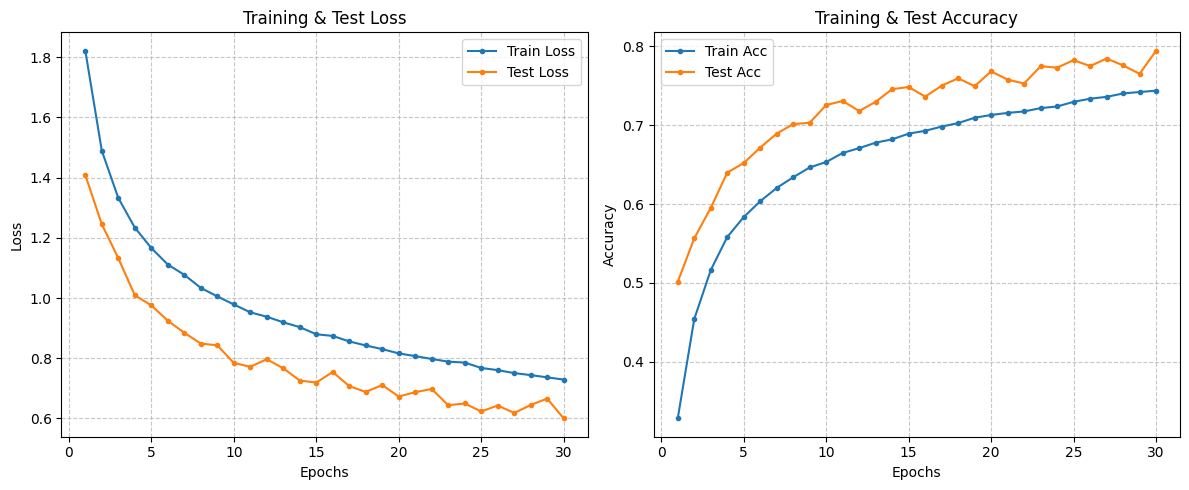

In [20]:
# param count
param_count = sum(p.numel() for p in model1.parameters())
print(f"Total parameters: {param_count}")

# plot training curves
epochs = range(1, len(history1['train_loss']) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history1['train_loss'], label='Train Loss', marker='.')
plt.plot(epochs, history1['test_loss'], label='Test Loss', marker='.')
plt.title('Training & Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs, history1['train_acc'], label='Train Acc', marker='.')
plt.plot(epochs, history1['test_acc'], label='Test Acc', marker='.')
plt.title('Training & Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Final Accuracy:  0.7943


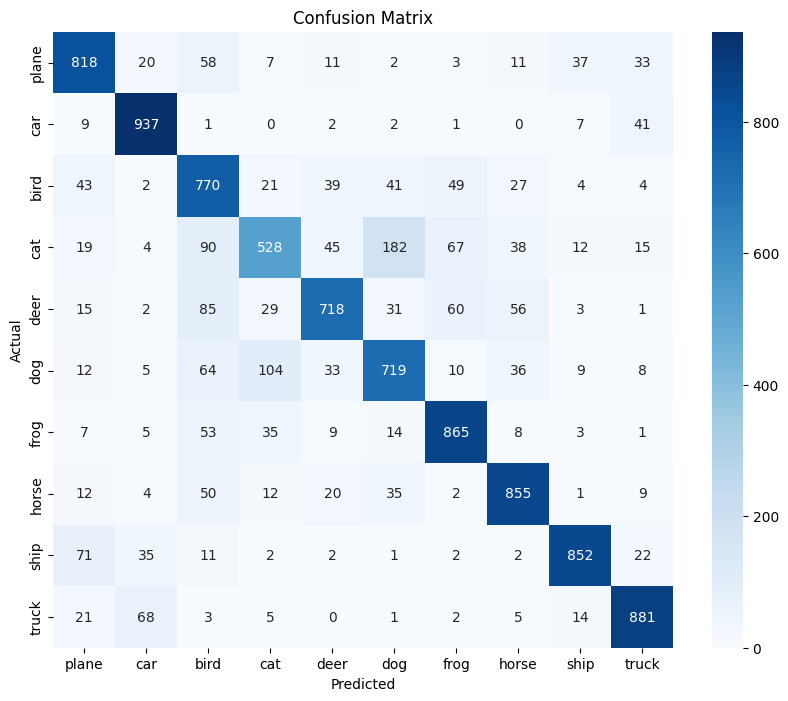

In [21]:
# final test accuracy & confusion matrix
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model1(images)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

final_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print("Final Accuracy: ", final_acc)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CIFAR_CLASSES,
    yticklabels=CIFAR_CLASSES
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Task 2) Improve your CNN
Modify your CNN to include identity (skip) connections where shapes
match (e.g., two convs per block), and projection when they don’t (1×1 conv).
Make sure to follow the below specifications:
- Keep overall depth and parameter budget comparable (±20% is fine).
- Reuse the same optimizer/augments unless you justify changes.
- Train and compare against Part A.

## Description of Approach
a

In [22]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, padding=1, bias=False
        )
        self.bn = nn.BatchNorm2d(out_channels)

        if in_channels != out_channels:
            self.proj = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
            self.proj_bn = nn.BatchNorm2d(out_channels)
        else:
            self.proj = None

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x

        out = self.conv(x)
        out = self.bn(out)

        if self.proj is not None:
            identity = self.proj(identity)
            identity = self.proj_bn(identity)

        out += identity
        out = self.relu(out)

        return out


class SkipCNNEncoder(nn.Module):
    def __init__(self, in_channels=3, latent_ch=128):
        super().__init__()
        self.dropout = nn.Dropout(0.5)

        self.block1 = ResidualBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.block2 = ResidualBlock(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.block3 = ResidualBlock(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc = nn.Linear(
            in_features=256 * 4 * 4, out_features=latent_ch
        )

    def forward(self, x):
        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.pool3(self.block3(x))

        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [23]:
model2 = EncoderWrapper(encoder=SkipCNNEncoder()).to(device)
opt2 = torch.optim.SGD(
    model2.parameters(), lr=0.001, weight_decay=1e-4, momentum=0.9
)
criterion2 = nn.CrossEntropyLoss()

history2 = train_model(model2, criterion2, opt2, train_loader)

ep0: tr_loss: 1.798, tr_acc: 0.339 | te_loss: 1.405, te_acc: 0.495
ep1: tr_loss: 1.476, tr_acc: 0.460 | te_loss: 1.223, te_acc: 0.557
ep2: tr_loss: 1.343, tr_acc: 0.513 | te_loss: 1.092, te_acc: 0.608
ep3: tr_loss: 1.247, tr_acc: 0.552 | te_loss: 1.007, te_acc: 0.645
ep4: tr_loss: 1.182, tr_acc: 0.575 | te_loss: 0.974, te_acc: 0.652
ep5: tr_loss: 1.135, tr_acc: 0.595 | te_loss: 0.918, te_acc: 0.674
ep6: tr_loss: 1.088, tr_acc: 0.613 | te_loss: 0.904, te_acc: 0.686
ep7: tr_loss: 1.056, tr_acc: 0.625 | te_loss: 0.910, te_acc: 0.677
ep8: tr_loss: 1.026, tr_acc: 0.638 | te_loss: 0.851, te_acc: 0.695
ep9: tr_loss: 1.005, tr_acc: 0.641 | te_loss: 0.838, te_acc: 0.699
ep10: tr_loss: 0.974, tr_acc: 0.655 | te_loss: 0.791, te_acc: 0.721
ep11: tr_loss: 0.954, tr_acc: 0.662 | te_loss: 0.821, te_acc: 0.716
ep12: tr_loss: 0.937, tr_acc: 0.668 | te_loss: 0.825, te_acc: 0.707
ep13: tr_loss: 0.919, tr_acc: 0.676 | te_loss: 0.755, te_acc: 0.732
ep14: tr_loss: 0.904, tr_acc: 0.680 | te_loss: 0.784, te_a

# Task 3) Self-Supervised Pretraining + Fine-tuning
Pretrain either your vanilla CNN or residual CNN without labels, then
fine-tune on labeled CIFAR-10, with the following specifications:
- Choose one SSL strategy from the below list:
  * Predictive: Rotation prediction (0/90/180/270) or patch jigsaw.
  * Contrastive: SimCLR-style instance discrimination (two strong
views).
  * Masked modeling / reconstruction: Mask random patches and
predict pixels/features.
- Follow the below training protocol:
  * Pretrain on the entire unlabeled CIFAR-10 train set (labels
hidden).
  * Evaluation B (Fine-tune): Unfreeze and fine-tune end-to-end
with 10% labeled data (make sure to sample uniformly across
classes!).

## Description of Approach
a

In [24]:
class SimCLRTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return self.transform(x), self.transform(x)

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]

        features = torch.cat([z_i, z_j], dim=0)

        features = F.normalize(features, dim=1)
        similarity_matrix = torch.matmul(features, features.T)

        labels = torch.cat([
            torch.arange(batch_size) + batch_size,
            torch.arange(batch_size)
        ], dim=0).to(features.device)

        mask = torch.eye(labels.shape[0], dtype=torch.bool).to(features.device)
        similarity_matrix.masked_fill_(mask, -9e15)

        logits = similarity_matrix / self.temperature
        loss = F.cross_entropy(logits, labels)
        return loss

def get_balanced_10_percent_subset(dataset, num_classes=10):
    indices = []
    targets = np.array(dataset.targets)
    for c in range(num_classes):
        class_indices = np.where(targets == c)[0]
        n_samples = int(len(class_indices) * 0.10)
        selected = np.random.choice(class_indices, n_samples, replace=False)
        indices.extend(selected)

    return Subset(dataset, indices)

In [25]:
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])
simclr_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=SimCLRTransform(simclr_transform),
    download=True
)
simclr_loader = torch.utils.data.DataLoader(
    simclr_dataset,
    batch_size=96,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

model_simclr = EncoderWrapper(
    encoder=SimpleCNNEncoder(), output_dim=64
).to(device)
opt_simclr = torch.optim.SGD(
    model_simclr.parameters(), lr=0.001, weight_decay=1e-4, momentum=0.9
)
criterion_simclr = NTXentLoss(temperature=0.5)

sub10_dataset = get_balanced_10_percent_subset(train_dataset)
sub10_loader = torch.utils.data.DataLoader(
    sub10_dataset, batch_size=96, shuffle=True, num_workers=2
)

In [26]:
print("--- Starting SimCLR Pretraining ---")
for epoch in range(15):
    model_simclr.train()
    total_loss = 0
    for (img1, img2), _ in simclr_loader:
        img1 = img1.to(device)
        img2 = img2.to(device)

        opt_simclr.zero_grad()

        z1 = model_simclr(img1)
        z2 = model_simclr(img2)

        loss = criterion_simclr(z1, z2)

        loss.backward()
        opt_simclr.step()

        total_loss += loss.item()

    print(f"SimCLR Epoch {epoch+1}: Loss {total_loss / len(simclr_loader):.4f}")

model3 = EncoderWrapper(encoder=model_simclr.encoder, output_dim=10).to(device)
criterion3 = nn.CrossEntropyLoss()

for param in model3.encoder.parameters():
    param.requires_grad = False

opt3_head = torch.optim.SGD(model3.head.parameters(), lr=0.001, momentum=0.9)

print("--- Step A: Linear Probing (Head Only) ---")
for epoch in range(5):
    model3.train()
    for images, labels in sub10_loader:
        images = images.to(device)
        labels= labels.to(device)

        opt3_head.zero_grad()
        logits = model3(images)

        loss = criterion3(logits, labels)
        loss.backward()

        opt3_head.step()

    print(f"Warmup Epoch {epoch+1} Done")

print("--- Step B: Full Fine-Tuning (Unfrozen) ---")
for param in model3.encoder.parameters():
    param.requires_grad = True

opt3_full = torch.optim.SGD(model3.parameters(), lr=0.001, momentum=0.9)
train_model(model3, criterion3, opt3_full, sub10_loader)

--- Starting SimCLR Pretraining ---
SimCLR Epoch 1: Loss 4.5035
SimCLR Epoch 2: Loss 4.3167
SimCLR Epoch 3: Loss 4.2544
SimCLR Epoch 4: Loss 4.2054
SimCLR Epoch 5: Loss 4.1751
SimCLR Epoch 6: Loss 4.1536
SimCLR Epoch 7: Loss 4.1428
SimCLR Epoch 8: Loss 4.1290
SimCLR Epoch 9: Loss 4.1151
SimCLR Epoch 10: Loss 4.1106
SimCLR Epoch 11: Loss 4.1015
SimCLR Epoch 12: Loss 4.0940
SimCLR Epoch 13: Loss 4.0879
SimCLR Epoch 14: Loss 4.0830
SimCLR Epoch 15: Loss 4.0734
--- Step A: Linear Probing (Head Only) ---
Warmup Epoch 1 Done
Warmup Epoch 2 Done
Warmup Epoch 3 Done
Warmup Epoch 4 Done
Warmup Epoch 5 Done
--- Step B: Full Fine-Tuning (Unfrozen) ---
ep0: tr_loss: 1.733, tr_acc: 0.364 | te_loss: 1.593, te_acc: 0.403
ep1: tr_loss: 1.598, tr_acc: 0.408 | te_loss: 1.559, te_acc: 0.414
ep2: tr_loss: 1.552, tr_acc: 0.429 | te_loss: 1.468, te_acc: 0.453
ep3: tr_loss: 1.495, tr_acc: 0.451 | te_loss: 1.399, te_acc: 0.489
ep4: tr_loss: 1.466, tr_acc: 0.463 | te_loss: 1.360, te_acc: 0.505
ep5: tr_loss: 1.

defaultdict(list,
            {'train_loss': [1.7328330541610717,
              1.5978835420608521,
              1.551745980834961,
              1.4954338947296142,
              1.466383644104004,
              1.434942631149292,
              1.3930288362503052,
              1.3985128803253173,
              1.3720466232299804,
              1.3447886558532716,
              1.3335019439697267,
              1.3257486663818359,
              1.2886590505599975,
              1.3005605211257936,
              1.2711432207107545,
              1.2456738414764403,
              1.247099779510498,
              1.2473197143554688,
              1.2296025978088378,
              1.2306752727508545,
              1.2033952747344971,
              1.2033373181343079,
              1.1909018354415895,
              1.1649926458358764,
              1.1755611434936524,
              1.1849472925186157,
              1.1493848344802857,
              1.12972794380188,
              1.140544